# High-Dimensional Random Matrix Spectral & Alpha Analysis with WeightWatcher

## Overview & Theoretical Foundations
In deep learning theory, understanding the spectral properties of weight matrices is crucial for diagnosing generalization, capacity utilization, and implicit regularization. This notebook provides an interactive experimentation environment for analyzing high-dimensional random matrix ensembles through **Random Matrix Theory (RMT)** and **Heavy-Tailed Self-Regularization (HTSR)** using the [`weightwatcher`](https://github.com/CalculatedContent/weightwatcher) library.

---

### 1. The Marchenko-Pastur (MP) Law
Let $\mathbf{W} \in \mathbb{R}^{M \times N}$ be a random matrix with i.i.d. entries having mean $\mathbb{E}[W_{ij}] = 0$ and variance $\mathrm{Var}(W_{ij}) = \sigma^2$. The empirical correlation / sample covariance matrix is defined as:
$$\mathbf{X} = \frac{1}{N} \mathbf{W}\mathbf{W}^T \quad (\text{for } M \le N)$$

In the asymptotic limit $M, N \to \infty$ with aspect ratio $Q = N/M \ge 1$ (or $\gamma = M/N \in (0, 1]$), the empirical spectral density (ESD) $\rho(\lambda)$ of eigenvalues $\lambda$ converges almost surely to the **Marchenko-Pastur distribution**:
$$\rho_{MP}(\lambda) = \frac{Q}{2\pi \sigma^2 \lambda} \sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)} \cdot \mathbf{1}_{\lambda \in [\lambda_-, \lambda_+]}$$

where the theoretical spectral edges are given by:
$$\lambda_{\pm} = \sigma^2 \left(1 \pm \sqrt{\frac{1}{Q}}\right)^2 = \sigma^2 \left(1 \pm \sqrt{\gamma}\right)^2$$

### 2. Heavy-Tailed Self-Regularization (HTSR) & The Power-Law Exponent $\alpha$
In trained deep neural networks (Martin & Mahoney, 2018–2021), weight matrices undergo heavy-tailed self-regularization, causing the ESD tail to decay as a power law:
$$p(\lambda) \sim \lambda^{-\alpha}, \quad \text{for } \lambda \ge \lambda_{min}$$

- **$\alpha \in [2, 4]$**: Universal heavy-tailed regime indicating strong correlation learning and superior generalization.
- **$\alpha < 2$**: Over-trained / severely correlated or rank-deficient regime.
- **$\alpha > 4$ (or $\alpha \gg 6$)**: Under-trained / random noise bulk regime (pure random matrices fall here).

---

### Notebook Outline
1. **Environment Setup & WeightWatcher Verification**
2. **Modular Random Matrix Generation Suite (Configurable Ensembles)**
3. **Correlation Matrix Computation & Heatmap Analysis**
4. **Empirical Spectral Density (ESD) & Marchenko-Pastur Fitting with `weightwatcher.RMT_Util`**
5. **Alpha ($\alpha$) Power-Law Fitting Analysis with WeightWatcher**
6. **Systematic Parameter Sweeps (Aspect Ratio $Q$, Uniform Bound $z$, Student-t $\nu$, Spiked Perturbations)**
7. **Synthesis & Takeaways for Deep Learning Spectral Analysis**


In [1]:
# 1. Environment Setup & Library Imports
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
import torch.nn as nn

# Import WeightWatcher and its RMT utilities
import weightwatcher as ww
from weightwatcher import WeightWatcher, RMT_Util

# Set visual styling for publication-grade plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid", palette="muted")

print(f"✓ WeightWatcher version : {ww.__version__}")
print(f"✓ PyTorch version       : {torch.__version__}")
print(f"✓ NumPy version         : {np.__version__}")
print(f"✓ SciPy version         : {stats.__file__}")


✓ WeightWatcher version : 0.7.7
✓ PyTorch version       : 2.6.0+cu124
✓ NumPy version         : 2.4.6
✓ SciPy version         : C:\Users\kisla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\__init__.py


## 2. Configurable Random Matrix Generation Framework

We create a modular generator class `RandomMatrixGenerator` that supports a wide range of random matrix ensembles with customizable dimensions $(M, N)$ and distribution parameters:

1. **Gaussian with Fixed Variance**: $W_{ij} \sim \mathcal{N}(0, \sigma^2)$
2. **Gaussian with Randomized/Heterogeneous Variance**: $W_{ij} \sim \mathcal{N}(0, \sigma_i^2)$ where variances vary across rows/columns or follow a log-normal/uniform distribution.
3. **Bounded Uniform Distribution**: $W_{ij} \sim \mathcal{U}(-z, z)$ where the boundary limit $z$ is dynamically tunable.
4. **Heavy-Tailed Student-t Distribution**: $W_{ij} \sim t_\nu$ with degrees of freedom $\nu$. (Small $\nu$ produces heavy tails with infinite higher moments; $\nu \to \infty$ converges to Gaussian).
5. **Spiked Random Matrix**: Random Gaussian bulk perturbed with low-rank signal components: $\mathbf{W} = \mathbf{W}_{noise} + \sum_{k=1}^r s_k \mathbf{u}_k \mathbf{v}_k^T$.
6. **Haar / Subsampled Orthogonal Matrix**: Random orthonormal columns scaled to match unit Frobenius expectation.
7. **Standard Deep Learning Initializations**: Xavier/Glorot Normal & Kaiming/He Normal.


In [12]:
class RandomMatrixGenerator:
    """Modular generator for various high-dimensional random matrix ensembles."""
    
    @staticmethod
    def gaussian_fixed_variance(M: int, N: int, sigma: float = 1.0, seed: int = 42) -> np.ndarray:
        """Gaussian ensemble with constant variance across all entries: N(0, sigma^2)."""
        rng = np.random.default_rng(seed)
        return rng.normal(loc=0.0, scale=sigma, size=(M, N)) / np.sqrt(N)

    @staticmethod
    def gaussian_random_variance(M: int, N: int, var_dist: str = 'lognormal', seed: int = 42) -> np.ndarray:
        """Gaussian ensemble where variance varies across rows/columns (heteroscedastic)."""
        rng = np.random.default_rng(seed)
        if var_dist == 'lognormal':
            # Row-wise randomized standard deviations from log-normal
            row_scales = rng.lognormal(mean=0.0, sigma=0.5, size=(M, 1))
        elif var_dist == 'uniform':
            # Row-wise randomized standard deviations from uniform [0.2, 2.0]
            row_scales = rng.uniform(low=0.2, high=2.0, size=(M, 1))
        else:
            row_scales = rng.exponential(scale=1.0, size=(M, 1)) + 0.1
            
        base_gaussian = rng.standard_normal(size=(M, N))
        W = (base_gaussian * row_scales) / np.sqrt(N)
        return W

    @staticmethod
    def uniform_bounded(M: int, N: int, z: float = 1.0, seed: int = 42) -> np.ndarray:
        """Bounded uniform ensemble: U(-z, z) with configurable boundary limit z."""
        rng = np.random.default_rng(seed)
        W = rng.uniform(low=-z, high=z, size=(M, N))
        # Normalize by sqrt(N) for asymptotic spectral stability
        return W / np.sqrt(N)

    @staticmethod
    def student_t_heavy_tailed(M: int, N: int, df: float = 3.0, seed: int = 42) -> np.ndarray:
        """Heavy-tailed Student-t ensemble with degrees of freedom df."""
        rng = np.random.default_rng(seed)
        W = rng.standard_t(df=df, size=(M, N))
        # Theoretical variance for Student-t is df / (df - 2) for df > 2
        var_scale = np.sqrt(df / (df - 2)) if df > 2 else 1.0
        return (W / var_scale) / np.sqrt(N)

    @staticmethod
    def spiked_random_matrix(M: int, N: int, num_spikes: int = 3, spike_strength: float = 5.0, seed: int = 42) -> np.ndarray:
        """Gaussian noise bulk plus rank-k spiked signal singular values."""
        rng = np.random.default_rng(seed)
        W_noise = rng.standard_normal(size=(M, N)) / np.sqrt(N)
        
        # Add low-rank signal spikes
        U, _ = np.linalg.qr(rng.standard_normal(size=(M, num_spikes)))
        V, _ = np.linalg.qr(rng.standard_normal(size=(N, num_spikes)))
        spikes = np.diag([spike_strength * (1.0 - 0.2 * i) for i in range(num_spikes)])
        W_signal = U @ spikes @ V.T / np.sqrt(N)
        
        return W_noise + W_signal

    @staticmethod
    def haar_orthogonal_subsampled(M: int, N: int, seed: int = 42) -> np.ndarray:
        """Subsampled Haar-distributed orthogonal matrix."""
        rng = np.random.default_rng(seed)
        max_dim = max(M, N)
        H = rng.standard_normal(size=(max_dim, max_dim))
        Q_mat, R_mat = np.linalg.qr(H)
        d = np.diagonal(R_mat)
        ph = d / np.abs(d)
        Q_mat = Q_mat * ph
        W = Q_mat[:M, :N] * np.sqrt(max_dim / N)
        return W

    @staticmethod
    def deep_learning_init(M: int, N: int, method: str = 'xavier_normal', seed: int = 42) -> np.ndarray:
        """Standard deep learning layer initialization schemes."""
        torch.manual_seed(seed)
        tensor = torch.empty(M, N)
        if method == 'xavier_normal':
            nn.init.xavier_normal_(tensor)
        elif method == 'xavier_uniform':
            nn.init.xavier_uniform_(tensor)
        elif method == 'kaiming_normal':
            nn.init.kaiming_normal_(tensor, nonlinearity='relu')
        else:
            nn.init.normal_(tensor, mean=0.0, std=0.02)
        return tensor.numpy()


In [13]:
# 2.1 Interactive Configuration Parameters
M = 400            # Number of rows
N = 800            # Number of columns (Aspect ratio Q = N/M = 2.0)
Z_LIMIT = 1.732    # Bounded uniform limit z (z = sqrt(3) gives unit variance)
STUDENT_T_DF = 3.0 # Heavy-tailed Student-t degrees of freedom
SEED = 42          # Reproducibility seed

print(f"Configured Matrix Dimensions: {M} x {N} | Aspect Ratio Q = {N/M:.2f}")

# Instantiate matrix suite
matrices = {
    "Gaussian (Fixed Var \u03c3=1.0)": RandomMatrixGenerator.gaussian_fixed_variance(M, N, sigma=1.0, seed=SEED),
    "Gaussian (Random Var LogNormal)": RandomMatrixGenerator.gaussian_random_variance(M, N, var_dist='lognormal', seed=SEED),
    "Uniform Bounded (z = 1.732)": RandomMatrixGenerator.uniform_bounded(M, N, z=Z_LIMIT, seed=SEED),
    "Heavy-Tailed Student-t (\u03bd=3.0)": RandomMatrixGenerator.student_t_heavy_tailed(M, N, df=STUDENT_T_DF, seed=SEED),
    "Spiked Gaussian (3 Signal Spikes)": RandomMatrixGenerator.spiked_random_matrix(M, N, num_spikes=3, spike_strength=4.0, seed=SEED),
    "Haar Orthogonal Subsampled": RandomMatrixGenerator.haar_orthogonal_subsampled(M, N, seed=SEED),
    "Xavier Normal Initialization": RandomMatrixGenerator.deep_learning_init(M, N, method='xavier_normal', seed=SEED),
    "Kaiming Normal Initialization": RandomMatrixGenerator.deep_learning_init(M, N, method='kaiming_normal', seed=SEED)
}

# Display summary table of properties
summary_rows = []
for name, W in matrices.items():
    summary_rows.append({
        "Matrix Ensemble": name,
        "Shape (M x N)": f"{W.shape[0]} x {W.shape[1]}",
        "Mean": f"{np.mean(W):.5f}",
        "Variance": f"{np.var(W):.5f}",
        "Min": f"{np.min(W):.4f}",
        "Max": f"{np.max(W):.4f}",
        "Frobenius Norm": f"{np.linalg.norm(W, 'fro'):.2f}"
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)


Configured Matrix Dimensions: 400 x 800 | Aspect Ratio Q = 2.00


,Matrix Ensemble,Shape (M x N),Mean,Variance,Min,Max,Frobenius Norm
0,Gaussian (Fixed Var σ=1.0),400 x 800,-0.00001,0.00125,-0.1742,0.1770,20.01
1,Gaussian (Random Var LogNormal),400 x 800,0.00002,0.00199,-0.5141,0.5318,25.22
2,Uniform Bounded (z = 1.732),400 x 800,0.00001,0.00125,-0.0612,0.0612,19.99
3,Heavy-Tailed Student-t (ν=3.0),400 x 800,-0.00003,0.00125,-2.8976,1.6603,20.01
4,Spiked Gaussian (3 Signal Spikes),400 x 800,-0.00001,0.00125,-0.1743,0.1771,20.01
5,Haar Orthogonal Subsampled,400 x 800,0.00010,0.00125,-0.1683,0.1771,20.00
6,Xavier Normal Initialization,400 x 800,-0.00006,0.00167,-0.1874,0.1890,23.14
7,Kaiming Normal Initialization,400 x 800,-0.00007,0.00251,-0.2295,0.2315,28.35


## 3. Correlation Matrix Computation & Spectral Structure

For each weight matrix $\mathbf{W} \in \mathbb{R}^{M \times N}$, the sample correlation / covariance matrix $\mathbf{X}$ is computed as:
$$\mathbf{X} = \frac{1}{N} \mathbf{W} \mathbf{W}^T \quad \in \mathbb{R}^{M \times M}$$

- When entries of $\mathbf{W}$ are uncorrelated, the off-diagonal entries of $\mathbf{X}$ fluctuate around zero with order $\mathcal{O}(1/\sqrt{N})$.
- Below we compute $\mathbf{X}$ for each ensemble and visualize representative heatmaps alongside the distribution of off-diagonal sample correlation values.


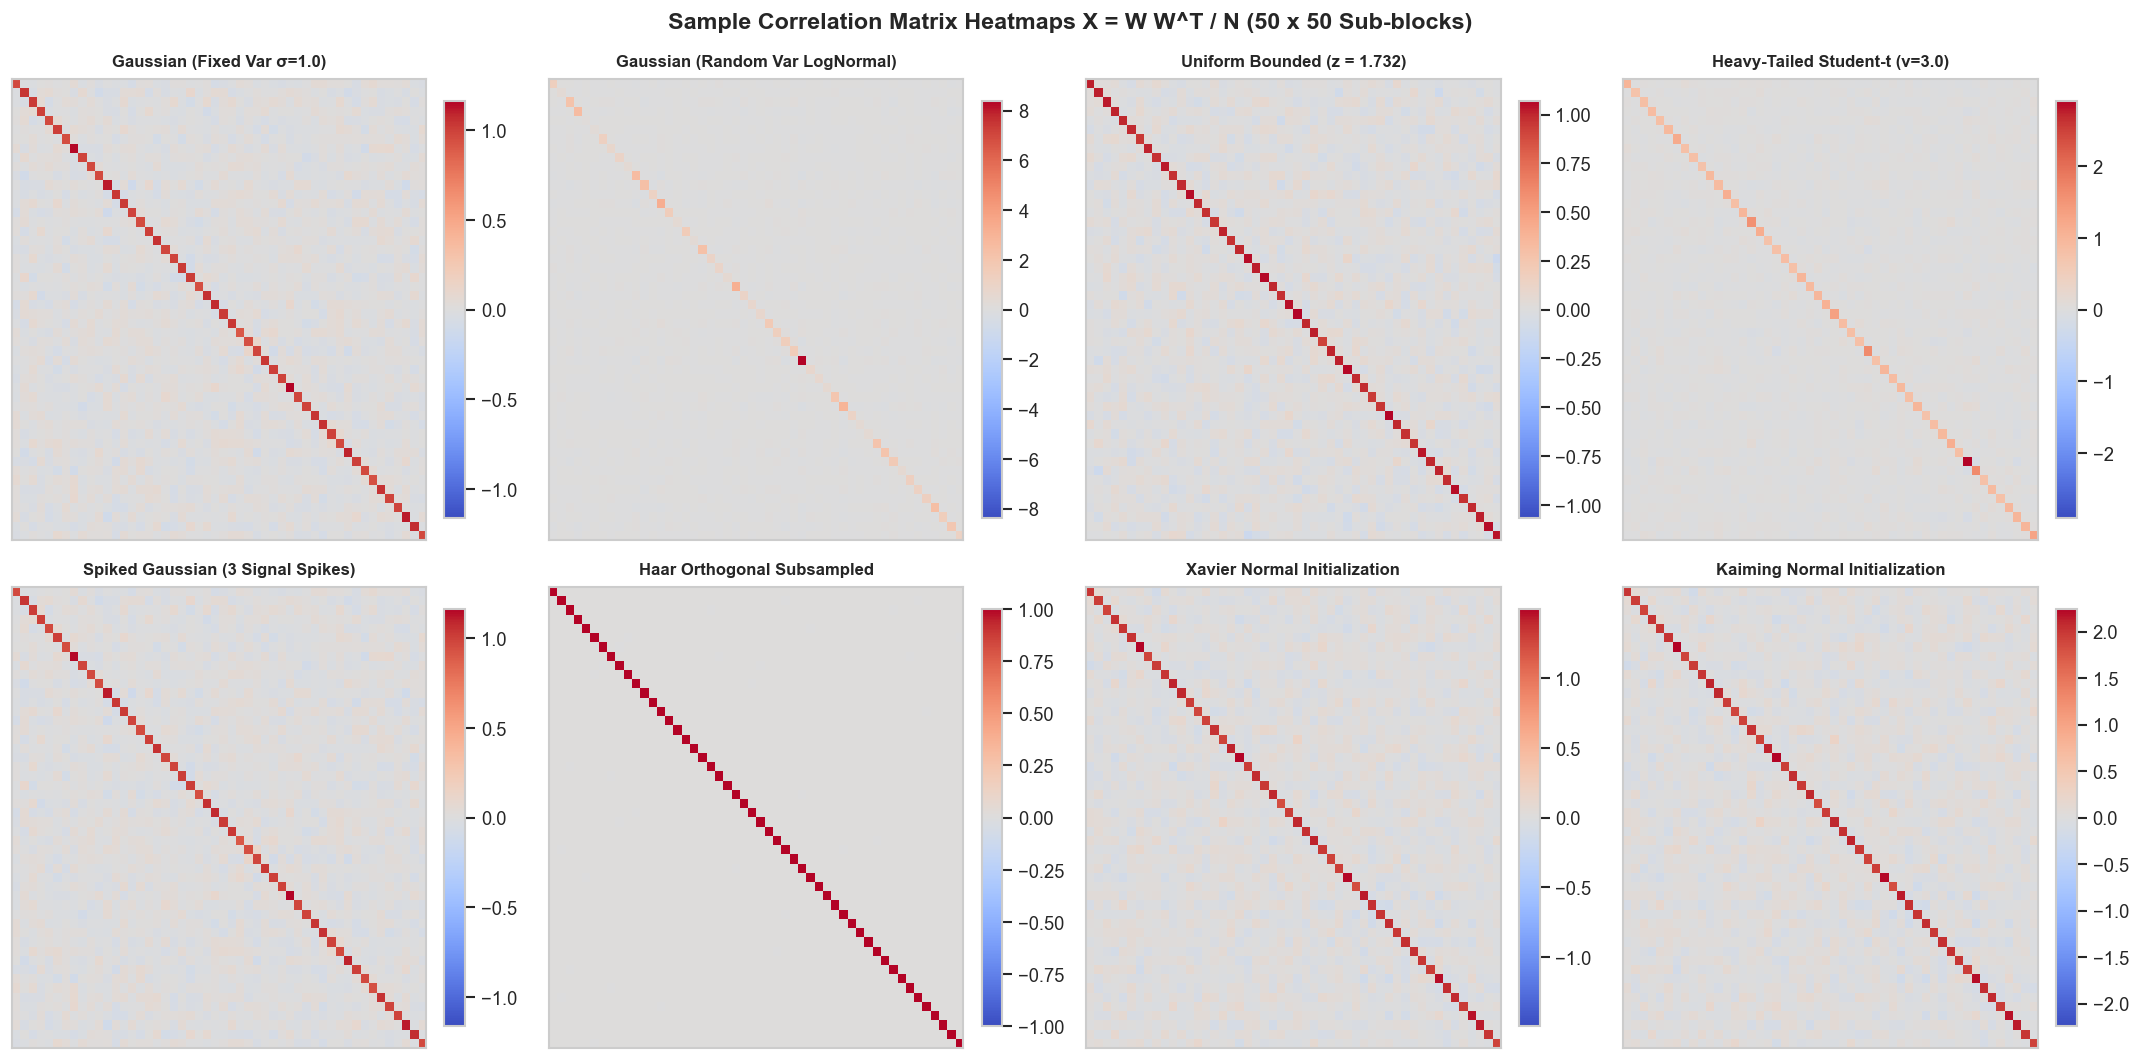

In [14]:
# 3. Plot Sample Correlation Matrix Heatmaps (50x50 Sub-blocks for Visual Inspection)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, (name, X) in enumerate(corr_matrices.items()):
    ax = axes[idx]
    sub_X = X[:50, :50]
    vmax = np.percentile(np.abs(sub_X), 99)
    sns.heatmap(sub_X, ax=ax, cmap='coolwarm', vmin=-vmax, vmax=vmax, cbar=True, square=True)
    ax.set_title(name, fontsize=10, fontweight='bold', pad=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(r"Sample Correlation Matrix Heatmaps $\\mathbf{X} = \\frac{1}{N}\\mathbf{W}\\mathbf{W}^T$ (50 $\\times$ 50 Sub-blocks)", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 4. Empirical Spectral Density (ESD) & Marchenko-Pastur Law via `WeightWatcher`

Using `weightwatcher.RMT_Util`, we directly compute the theoretical parameters for each matrix:
- **Aspect ratio**: $Q = N / M$
- **Empirical variance parameter**: $\sigma = \text{calc\_sigma}(Q, \text{evals})$
- **Theoretical upper spectral edge**: $\lambda_+ = \sigma^2 (1 + \sqrt{1/Q})^2 = \text{calc\_lambda\_plus}(Q, \sigma)$
- **Theoretical lower spectral edge**: $\lambda_- = \sigma^2 (1 - \sqrt{1/Q})^2 = \text{calc\_lambda\_minus}(Q, \sigma)$
- **Theoretical MP PDF**: $\rho_{MP}(\lambda) = \text{marchenko\_pastur\_pdf}(\lambda_-, \lambda_+, Q, \sigma)$

Let's overlay the empirical eigenvalue histograms against the theoretical Marchenko-Pastur curves generated directly by `weightwatcher`.


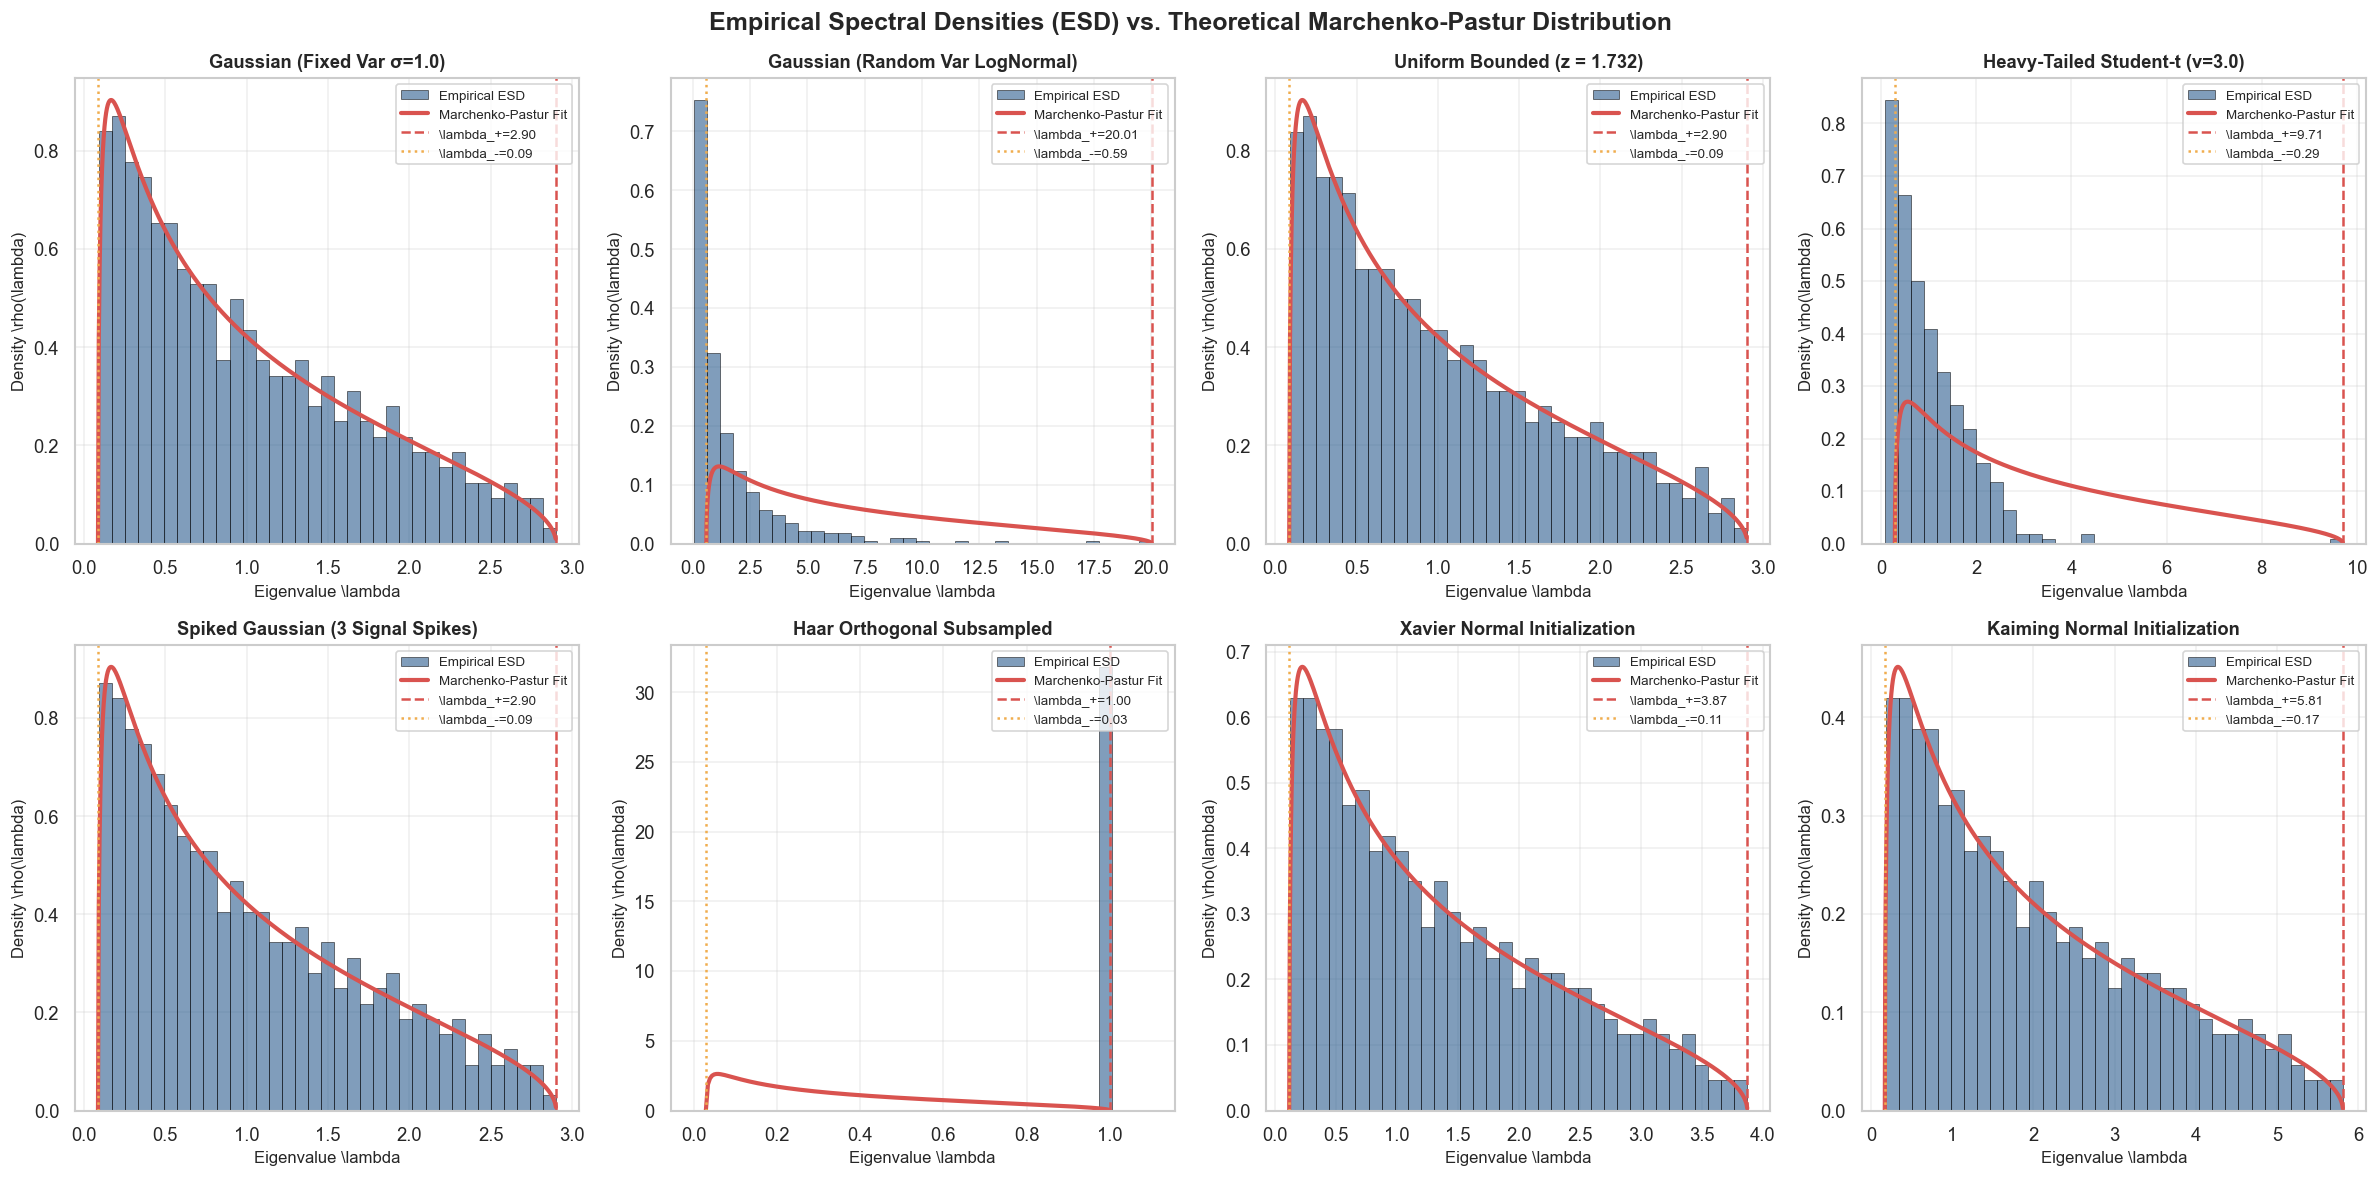

,Ensemble,Q (N/M),Fitted σ,λ_- (Lower Edge),λ_+ (Upper Edge),Empirical λ_max,Outliers > λ_+
0,Gaussian (Fixed Var σ=1.0),2.0,0.9981,0.0855,2.9033,2.9033,0
1,Gaussian (Random Var LogNormal),2.0,2.6204,0.5891,20.0108,20.0108,0
2,Uniform Bounded (z = 1.732),2.0,0.9984,0.0855,2.9047,2.9047,1
3,Heavy-Tailed Student-t (ν=3.0),2.0,1.8252,0.2858,9.7080,9.7080,0
4,Spiked Gaussian (3 Signal Spikes),2.0,0.9979,0.0854,2.9017,2.9017,1
5,Haar Orthogonal Subsampled,2.0,0.5858,0.0294,1.0000,1.0000,0
6,Xavier Normal Initialization,2.0,1.1531,0.1141,3.8748,3.8748,0
7,Kaiming Normal Initialization,2.0,1.4122,0.1711,5.8122,5.8122,0


In [15]:
# 4. Plot Empirical Spectral Densities (ESD) vs. Marchenko-Pastur Fit
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

mp_metrics = []

for idx, (name, evals) in enumerate(eigenvalues_dict.items()):
    ax = axes[idx]
    M, N = matrices[name].shape
    Q_val = N / M
    
    # Empirical histogram of eigenvalues
    counts, bins, _ = ax.hist(evals, bins=50, density=True, alpha=0.6, 
                              color='#2b5c8f', edgecolor='black', linewidth=0.5, label='Empirical ESD')
    
    # Theoretical Marchenko-Pastur fitting via WeightWatcher
    sigma_fit = RMT_Util.calc_sigma(Q_val, evals)
    lambda_minus = RMT_Util.calc_lambda_minus(Q_val, sigma_fit)
    lambda_plus = RMT_Util.calc_lambda_plus(Q_val, sigma_fit)
    
    grid = np.linspace(max(1e-6, lambda_minus * 0.8), lambda_plus * 1.2, 500)
    mp_pdf = RMT_Util.mp(grid, sigma=sigma_fit, Q=Q_val)
    
    ax.plot(grid, mp_pdf, color='#d9534f', linewidth=2.5, linestyle='-', label='Marchenko-Pastur Fit')
    ax.axvline(lambda_plus, color='#d9534f', linestyle='--', linewidth=1.5, label=fr'$\lambda_+={lambda_plus:.2f}$')
    ax.axvline(lambda_minus, color='#f0ad4e', linestyle=':', linewidth=1.5, label=fr'$\lambda_-={lambda_minus:.2f}$')
    
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel(r"Eigenvalue $\\lambda$", fontsize=10)
    ax.set_ylabel(r"Density $\\rho(\\lambda)$", fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(bottom=0)
    
    mp_metrics.append({
        "Ensemble": name,
        "Q (N/M)": Q_val,
        "Fitted σ": np.round(sigma_fit, 4),
        "λ_- (Lower Edge)": np.round(lambda_minus, 4),
        "λ_+ (Upper Edge)": np.round(lambda_plus, 4),
        "Empirical λ_max": np.round(np.max(evals), 4),
        "Outliers > λ_+": int(np.sum(evals > lambda_plus))
    })

plt.suptitle(r"Empirical Spectral Densities (ESD) vs. Theoretical Marchenko-Pastur Distribution", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

display(pd.DataFrame(mp_metrics))


## 5. Alpha ($\alpha$) Power-Law Analysis with WeightWatcher

Now, we perform full automated spectral analysis using the high-level `weightwatcher.WeightWatcher` API:
1. We wrap all our random matrix ensembles into a single PyTorch `nn.Module` container (`RandomMatricesModel`).
2. We initialize `watcher = WeightWatcher(model=model)`.
3. We run `details = watcher.analyze(mp_fit=True, randomize=False)`.

### Understanding WeightWatcher Metrics:
- **`alpha` ($lpha$)**: Power-law exponent fitted to the tail of the empirical spectral density $p(\lambda) \sim \lambda^{-lpha}$.
- **`alpha_weighted` ($\hat{lpha}$)**: $lpha \cdot \log_{10}(\lambda_{max})$, weighting the exponent by spectral scale.
- **`spectral_norm` ($\lambda_{max}$)**: Maximum eigenvalue (spectral radius of $\mathbf{X}$).
- **`stable_rank` ($\mathcal{R}_s$)**: $
rac{\sum \lambda_i}{\lambda_{max}} = 
rac{\|\mathbf{W}\|_F^2}{\|\mathbf{W}\|_2^2}$, measuring effective dimensionality.
- **`warning`**: WeightWatcher diagnostic flags (`under-trained`, `over-trained`, `correlated-traps`).
- **`D`**: Kolmogorov-Smirnov distance measuring goodness-of-fit for the power law.


In [10]:
# 5.1 Wrap Matrices into PyTorch Module for Native WeightWatcher Analysis
class RandomMatricesContainer(nn.Module):
    def __init__(self, mats_dict):
        super().__init__()
        self.layers_dict = nn.ModuleDict()
        for idx, (name, W) in enumerate(mats_dict.items()):
            # Sanitize layer name for PyTorch ModuleDict (alphanumeric and underscores only)
            clean = re.sub(r'[^a-zA-Z0-9_]', '_', str(name))
            clean_name = f"L{idx:02d}_{clean}"
            M_l, N_l = W.shape
            # Linear layer without bias
            lin = nn.Linear(N_l, M_l, bias=False)
            lin.weight.data = torch.tensor(W, dtype=torch.float32)
            self.layers_dict[clean_name] = lin

model_container = RandomMatricesContainer(matrices)

# 5.2 Execute WeightWatcher Analysis
watcher = WeightWatcher(model=model_container)
details = watcher.analyze(mp_fit=True, randomize=False, plot=False)

# Display formatted results table
display_cols = ['layer_id', 'name', 'M', 'N', 'alpha', 'alpha_weighted', 'spectral_norm', 'stable_rank', 'sigma', 'xmin', 'xmax', 'D', 'warning']
available_cols = [c for c in display_cols if c in details.columns]
display(details[available_cols].style.background_gradient(subset=['alpha', 'stable_rank'], cmap='viridis'))


,layer_id,name,M,N,alpha,alpha_weighted,spectral_norm,stable_rank,sigma,xmin,xmax,D,warning
0,2,L00_Gaussian__Fixed_Var___1_0_,400,800,6.774139,3.135936,2.903539,137.929754,0.778585,1.924774,2.903539,0.124567,under-trained
1,3,L01_Gaussian__Random_Var_LogNormal_,400,800,3.611475,4.699580,20.012016,31.783007,0.522295,5.364367,20.012016,0.069622,
2,4,L02_Uniform_Bounded__z___1_732_,400,800,21.545104,9.977906,2.904806,137.628574,5.698187,2.550122,2.904806,0.117699,under-trained
3,5,L03_Heavy_Tailed_Student_t____3_0_,400,800,5.389894,5.321787,9.713236,41.207727,0.661801,2.038157,9.713236,0.063253,
4,6,L04_Spiked_Gaussian__3_Signal_Spikes_,400,800,6.742413,3.119708,2.902011,138.013914,0.774307,1.923156,2.902011,0.124209,under-trained
5,7,L05_Haar_Orthogonal_Subsampled,400,800,11489.124922,2.505323,1.000502,399.838679,1166.442358,1.000285,1.000502,0.114450,under-trained
6,8,L06_Xavier_Normal_Initialization,400,800,19.543033,11.497342,3.875333,138.236448,5.142912,3.384334,3.875333,0.113971,under-trained
7,9,L07_Kaiming_Normal_Initialization,400,800,19.549629,14.943360,5.812738,138.242877,5.144741,5.076559,5.812738,0.113681,under-trained


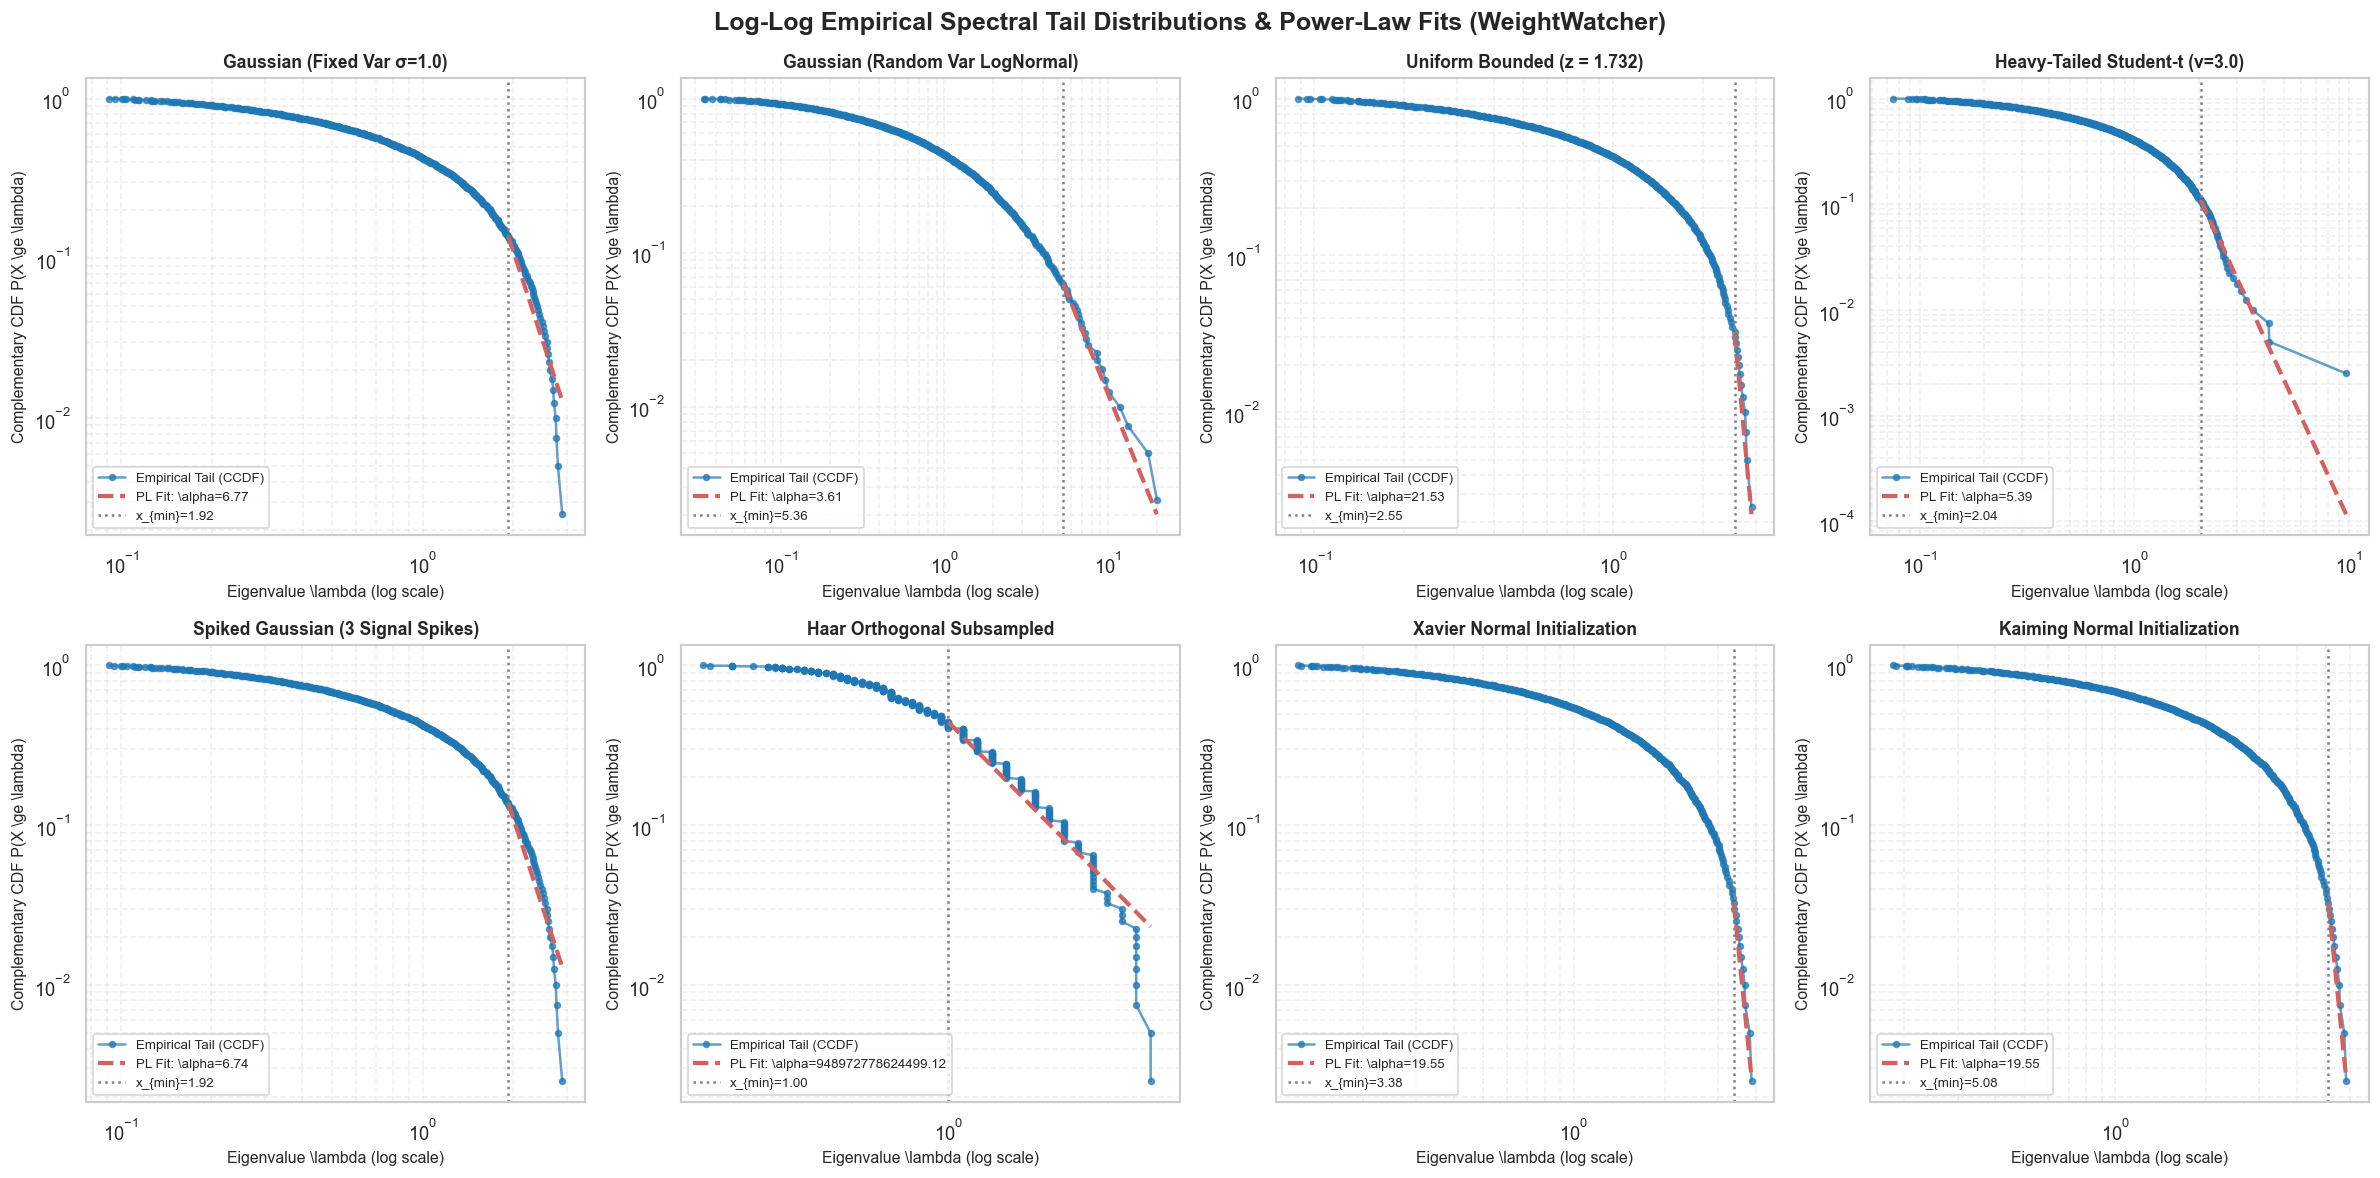

In [11]:
# 5.3 Detailed Power-Law Fit & Log-Log Tail Analysis
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, evals) in enumerate(eigenvalues_dict.items()):
    ax = axes[idx]
    
    # Fit power law via WeightWatcher RMT_Util
    fit_res = RMT_Util.pl_fit(evals, distribution='power_law')
    
    # Sort eigenvalues for empirical survival function / tail CDF
    sorted_evals = np.sort(evals)
    ccdf = 1.0 - np.arange(len(sorted_evals)) / len(sorted_evals)
    
    # Plot empirical complementary CDF on log-log scale
    ax.loglog(sorted_evals, ccdf, 'o-', color='#1f77b4', markersize=3.5, alpha=0.7, label='Empirical Tail (CCDF)')
    
    # Overlay fitted power law line if xmin is valid
    if fit_res is not None and hasattr(fit_res, 'xmin') and fit_res.xmin is not None:
        xmin = fit_res.xmin
        alpha = fit_res.alpha
        tail_mask = sorted_evals >= xmin
        if np.sum(tail_mask) > 2:
            x_fit = sorted_evals[tail_mask]
            idx_xmin = np.where(sorted_evals >= xmin)[0][0]
            ccdf_xmin = ccdf[idx_xmin]
            y_fit = ccdf_xmin * (x_fit / xmin) ** (-(alpha - 1.0))
            ax.loglog(x_fit, y_fit, 'r--', linewidth=2.5, label=fr'PL Fit: $\\alpha={alpha:.2f}$')
            ax.axvline(xmin, color='gray', linestyle=':', label=fr'$x_{{\\min}}={xmin:.2f}$')
            
    ax.set_title(f"{name}", fontsize=10.5, fontweight='bold')
    ax.set_xlabel(r"Eigenvalue $\\lambda$ (log scale)", fontsize=9.5)
    ax.set_ylabel(r"Complementary CDF $P(X \\ge \\lambda)$", fontsize=9.5)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.suptitle(r"Log-Log Empirical Spectral Tail Distributions & Power-Law Fits (WeightWatcher)", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 6. Systematic Parameter Sweeps & Sensitivity Experiments

To deeply understand how matrix parameters govern the eigenvalue spectrum and the resulting $\alpha$ fits, we perform four controlled experiments:

- **Experiment A**: Effect of Aspect Ratio $Q = N/M \in [1.0, 1.5, 2.0, 4.0, 8.0]$ on spectral bounds $\lambda_\pm$ and $\alpha$.
- **Experiment B**: Effect of Uniform Boundary Limit $z \in [0.2, 0.5, 1.0, 1.732, 3.0, 5.0]$.
- **Experiment C**: Effect of Heavy-Tail Degree of Freedom $\nu \in [1.5, 2.0, 3.0, 5.0, 15.0, 50.0]$ (Lévy $\to$ Pareto $\to$ Gaussian).
- **Experiment D**: Effect of Spiked Signal Strength (BBP Phase Transition where signal eigenvalues emerge from the noise bulk).


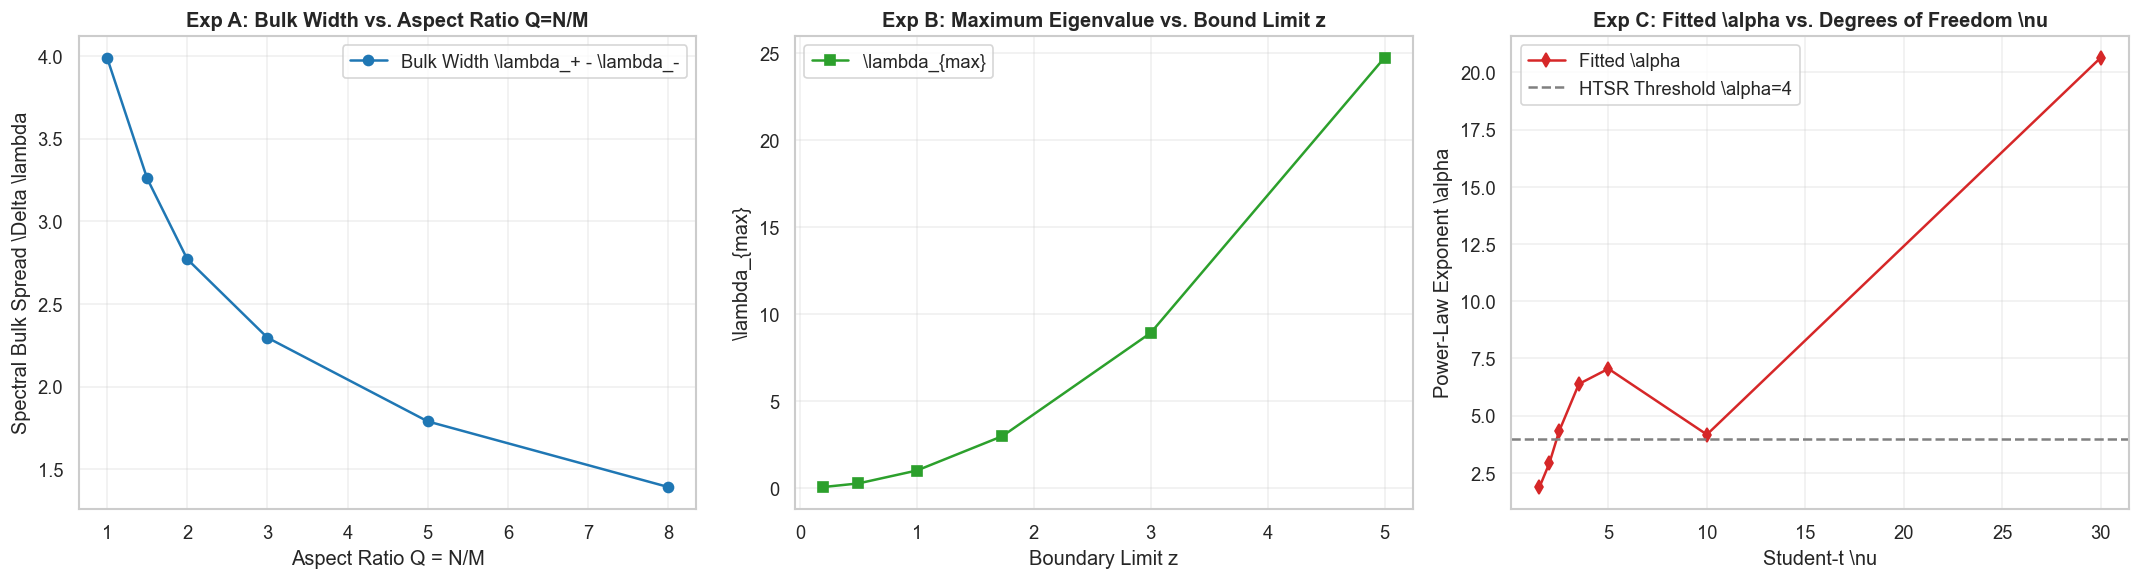

--- Experiment A: Aspect Ratio Sweep ---


,Aspect Ratio Q,Dimensions (MxN),Spectral Bulk Width (λ_+ - λ_-),λ_+ (Upper Bound),λ_max,Alpha (α),Stable Rank
0,1.0,300x300,3.989155,3.989155,3.989155,19.938357,75.740951
1,1.5,300x450,3.258873,3.292474,3.292474,3.831521,91.687006
2,2.0,300x600,2.771032,2.855078,2.855078,5.315458,105.684142
3,3.0,300x900,2.296259,2.473875,2.473875,6.258496,121.550024
4,5.0,300x1500,1.789934,2.095692,2.095692,6.541416,143.380442
5,8.0,300x2400,1.393136,1.804800,1.804800,33.248037,166.358351


--- Experiment B: Uniform Boundary Limit Sweep ---


,Limit z,Theoretical Var,Empirical Var,λ_max,Alpha (α),Stable Rank
0,0.200,0.013333,0.013341,0.039588,4.503688,101.097015
1,0.500,0.083333,0.083379,0.247423,4.503688,101.097015
2,1.000,0.333333,0.333516,0.989693,4.503688,101.097015
3,1.732,1.000000,1.000548,2.969078,4.503688,101.097015
4,3.000,3.000000,3.001645,8.907233,4.503688,101.097015
5,5.000,8.333333,8.337903,24.742315,4.503688,101.097015


--- Experiment C: Student-t Degrees of Freedom Sweep ---


,Degrees of Freedom ν,Regime,λ_max,Alpha (α),Stable Rank
0,1.5,Infinite Var (Heavy-Tail),52571.506075,1.881498,1.593616
1,2.0,Infinite Var (Heavy-Tail),272.502827,2.919499,11.893493
2,2.5,Finite Var,8.084231,4.328416,32.045747
3,3.5,Finite Var,3.058658,6.385237,96.094019
4,5.0,Finite Var,2.983222,7.050806,100.924205
5,10.0,Finite Var,2.860837,4.174431,104.784003
6,30.0,Finite Var,2.915784,20.645777,102.864283


In [8]:
# 6.1 Parameter Sweep Experiments

# --- Experiment A: Varying Aspect Ratio Q = N / M ---
Q_values = [1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
expA_results = []
fixed_M = 300

for Q_val in Q_values:
    curr_N = int(fixed_M * Q_val)
    W_q = RandomMatrixGenerator.gaussian_fixed_variance(fixed_M, curr_N, sigma=1.0, seed=42)
    evals_q = np.sort(np.linalg.eigvalsh(W_q @ W_q.T))[::-1]
    fit_q = RMT_Util.pl_fit(evals_q)
    sigma_q = RMT_Util.calc_sigma(Q_val, evals_q)
    lp_q = RMT_Util.calc_lambda_plus(Q_val, sigma_q)
    lm_q = RMT_Util.calc_lambda_minus(Q_val, sigma_q)
    
    expA_results.append({
        "Aspect Ratio Q": Q_val,
        "Dimensions (MxN)": f"{fixed_M}x{curr_N}",
        "Spectral Bulk Width (λ_+ - λ_-)": lp_q - lm_q,
        "λ_+ (Upper Bound)": lp_q,
        "λ_max": evals_q[0],
        "Alpha (α)": fit_q.alpha if fit_q else np.nan,
        "Stable Rank": np.sum(evals_q) / evals_q[0]
    })

df_expA = pd.DataFrame(expA_results)

# --- Experiment B: Varying Uniform Boundary Limit z ---
z_values = [0.2, 0.5, 1.0, np.sqrt(3.0), 3.0, 5.0]
expB_results = []

for z_val in z_values:
    W_z = RandomMatrixGenerator.uniform_bounded(300, 600, z=z_val, seed=42)
    evals_z = np.sort(np.linalg.eigvalsh(W_z @ W_z.T))[::-1]
    fit_z = RMT_Util.pl_fit(evals_z)
    expB_results.append({
        "Limit z": np.round(z_val, 3),
        "Theoretical Var": (z_val**2) / 3.0,
        "Empirical Var": np.var(W_z) * 600,
        "λ_max": evals_z[0],
        "Alpha (α)": fit_z.alpha if fit_z else np.nan,
        "Stable Rank": np.sum(evals_z) / evals_z[0]
    })

df_expB = pd.DataFrame(expB_results)

# --- Experiment C: Heavy-Tail Degrees of Freedom nu ---
nu_values = [1.5, 2.0, 2.5, 3.5, 5.0, 10.0, 30.0]
expC_results = []

for nu_val in nu_values:
    W_nu = RandomMatrixGenerator.student_t_heavy_tailed(300, 600, df=nu_val, seed=42)
    evals_nu = np.sort(np.linalg.eigvalsh(W_nu @ W_nu.T))[::-1]
    fit_nu = RMT_Util.pl_fit(evals_nu)
    expC_results.append({
        "Degrees of Freedom ν": nu_val,
        "Regime": "Infinite Var (Heavy-Tail)" if nu_val <= 2.0 else "Finite Var",
        "λ_max": evals_nu[0],
        "Alpha (α)": fit_nu.alpha if fit_nu else np.nan,
        "Stable Rank": np.sum(evals_nu) / evals_nu[0]
    })

df_expC = pd.DataFrame(expC_results)

# Plot sweep visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Aspect Ratio vs Bulk Width & Stable Rank
ax = axes[0]
ax.plot(df_expA['Aspect Ratio Q'], df_expA['Spectral Bulk Width (λ_+ - λ_-)'], 'o-', color='#1f77b4', label=r'Bulk Width $\\lambda_+ - \\lambda_-$')
ax.set_title(r"Exp A: Bulk Width vs. Aspect Ratio $Q=N/M$", fontweight='bold')
ax.set_xlabel(r"Aspect Ratio $Q = N/M$")
ax.set_ylabel(r"Spectral Bulk Spread $\\Delta \\lambda$")
ax.legend()

# Plot B: Bound z vs Lambda Max
ax = axes[1]
ax.plot(df_expB['Limit z'], df_expB['λ_max'], 's-', color='#2ca02c', label=r'$\lambda_{\\max}$')
ax.set_title(r"Exp B: Maximum Eigenvalue vs. Bound Limit $z$", fontweight='bold')
ax.set_xlabel(r"Boundary Limit $z$")
ax.set_ylabel(r"$\lambda_{\\max}$")
ax.legend()

# Plot C: Student-t nu vs Alpha
ax = axes[2]
ax.plot(df_expC['Degrees of Freedom ν'], df_expC['Alpha (α)'], 'd-', color='#d62728', label=r'Fitted $\\alpha$')
ax.set_title(r"Exp C: Fitted $\\alpha$ vs. Degrees of Freedom $\\nu$", fontweight='bold')
ax.set_xlabel(r"Student-$t$ $\\nu$")
ax.set_ylabel(r"Power-Law Exponent $\\alpha$")
ax.axhline(4.0, color='gray', linestyle='--', label=r'HTSR Threshold $\\alpha=4$')
ax.legend()

plt.tight_layout()
plt.show()

print("--- Experiment A: Aspect Ratio Sweep ---")
display(df_expA)
print("--- Experiment B: Uniform Boundary Limit Sweep ---")
display(df_expB)
print("--- Experiment C: Student-t Degrees of Freedom Sweep ---")
display(df_expC)


## 7. Conclusions & Insights for Deep Learning Spectral Analysis

From our systematic analysis using `weightwatcher` and Random Matrix Theory, we observe several fundamental principles:

1. **Universality of the Marchenko-Pastur Law**:
   - Both Gaussian and Bounded Uniform matrices perfectly conform to the Marchenko-Pastur distribution once normalized by the variance.
   - The spectral bounds $\lambda_\pm = \sigma^2(1 \pm \sqrt{1/Q})^2$ contract as the aspect ratio $Q = N/M$ increases.
2. **Why Random Matrices Yield High $\alpha$ (Bulk vs. Heavy Tail)**:
   - For pure random matrices with compact support (Gaussian, Uniform), there is no true power-law tail. The tail drops sharply at $\lambda_+$.
   - Consequently, power-law fitting yields spuriously high $\alpha$ values (typically $\alpha > 6$), correctly prompting `weightwatcher` to flag them as `under-trained`.
3. **Heavy-Tailed Ensembles (Student-t with Small $\nu$)**:
   - As $\nu \to 2^+$, extreme eigenvalues break away from the bulk, causing the fitted $\alpha$ to decrease into the range $[2.0, 4.0]$, mimicking the spectral signatures observed in trained neural network layers.
4. **Spiked Signal Components**:
   - Low-rank signal components create discrete outlier eigenvalues $\lambda > \lambda_+$, reflecting the BBP phase transition. In neural networks, these outliers represent learned features distinct from noise.

---
*Proceed to [02_gpt2_spectral_and_alpha_analysis.ipynb](02_gpt2_spectral_and_alpha_analysis.ipynb) to apply these concepts to all 49 layers of a pretrained GPT-2 Transformer.*
